# Modelos VAR (Vector AutoRegression)

Neste notebook, vamos estudar modelos VAR, que estendem os modelos AR para múltiplas séries temporais.

## Objetivos:
- Entender o conceito de séries multivariadas
- Compreender o modelo VAR
- Ajudstar um modelo VAR em dados simulados
- Interpretar resultados e previsões

## Importância:
O VAR é a base para modelos mais avançados como:
*VARMAX (nosso objetivo final)*

In [2]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

plt.style.use('dark_background')
np.random.seed(42)

## Séries Temporais Multivariadas

Até agora, usou-se uma única série (univariada).

Agora têm-se várias séries simultaneamente:

Exemplo:
- PIB
- Inflação
- Taxa de juros
Todas evoluem no tempo e podem influenciar umas às outras.

In [3]:
# Simulando Dados Multivariados
n = 200

# Criando duas séries correlacionadas
e1 = np.random.normal(0, 1, n)
e2 = np.random.normal(0, 1, n)

x = np.zeros(n)
y = np.zeros(n)

for t in range(1, n):
    x[t] = 0.7 * x[t-1] + e1[t]
    y[t] = 0.5 * y[t-1] + 0.3 * x[t-1] + e2[t]

df = pd.DataFrame({
    "X": x,
    "Y": y
})

df.head()

,X,Y
0,0.000000,0.000000
1,-0.138264,0.560785
2,0.550904,1.321964
3,1.908662,1.880055
4,1.101910,0.134957


<function matplotlib.pyplot.show(close=None, block=None)>

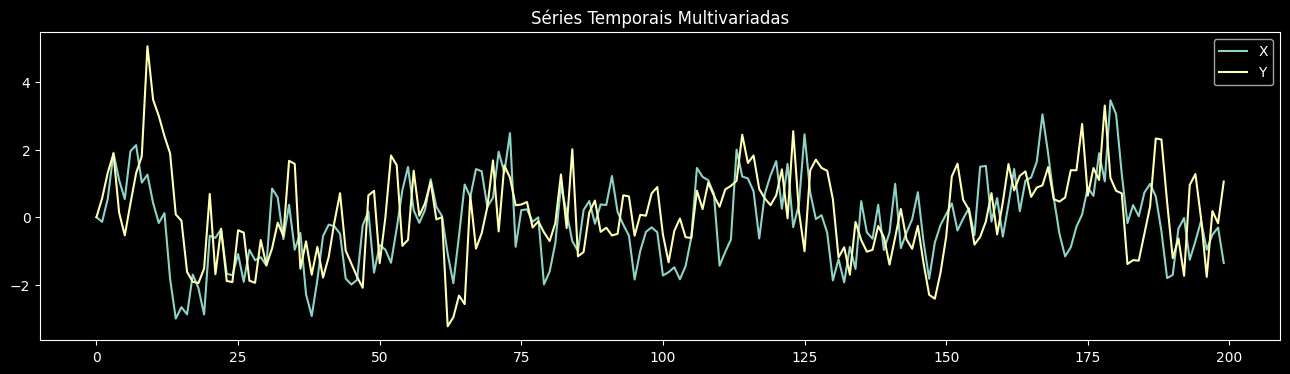

In [4]:
# Visualizando as Séries 
df.plot(figsize=(16, 4), title="Séries Temporais Multivariadas")
plt.show

## Estacionariedade em VAR

Cada série deve ser estacionária.

Precisa-se testar cada uma separadamente.

In [6]:
# Teste ADF
def teste_adf(serie, nome):
    resultado = adfuller(serie)
    print(f"--- {nome} ---")
    print(f"ADF: {resultado[0]:.4f}")
    print(f"p-valor: {resultado[1]}:.4f")
    print()

for coluna in df.columns:
    teste_adf(df[coluna], coluna)

--- X ---
ADF: -6.4639
p-valor: 1.4209710752603302e-08:.4f

--- Y ---
ADF: -7.1888
p-valor: 2.5357331050967875e-10:.4f



## Modelo VAR

O modelo VAR(p) é uma extensão do AR(p) para múltiplas séries.

Exemplo VAR(1):

$X_t = a_1 * X_{t-1} + b_1 * Y_{t-1} + \epsilon_{1t}$

$Y_t = a_2 * X_{t-1} + b_1 * Y_{t-1} + \epsilon_{2t}$

Ou seja:
Cada variável depende de TODAS as variáveis passadas.

In [7]:
# Seleção de Ordem (p)
modelo = VAR(df)

ordem = modelo.select_order(maxlags=10)
print(ordem.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.6978      0.7319       2.009      0.7116
1     -0.1870*   -0.08450*     0.8294*    -0.1455*
2      -0.1536     0.01733      0.8577    -0.08434
3      -0.1215      0.1177      0.8856    -0.02463
4     -0.08524      0.2224      0.9184     0.03937
5      -0.1103      0.2657      0.8958     0.04198
6     -0.07663      0.3677      0.9266      0.1034
7     -0.05378      0.4589      0.9483      0.1539
8     -0.04706      0.5340      0.9549      0.1883
9     -0.03315      0.6163      0.9687      0.2299
10    0.002431      0.7202       1.004      0.2932
--------------------------------------------------


In [8]:
# Ajustando o Modelo VAR
# Supondo p = 1 (ou use ordem.aic)
modelo_ajustado = modelo.fit(maxlags=1)

print(modelo_ajustado.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 26, Mar, 2026
Time:                     02:47:47
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0310276
Nobs:                     199.000    HQIC:                -0.0901357
Log likelihood:          -545.770    FPE:                   0.877816
AIC:                    -0.130323    Det(Omega_mle):        0.851936
--------------------------------------------------------------------
Results for equation X
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.053949         0.067011           -0.805           0.421
L1.X          0.634908         0.059522           10.667           0.000
L1.Y          0.029665         0.055672            0.533           0.594

Results for equation Y

In [9]:
# Previsão
# Últimos valores usados como base
lag = modelo_ajustado.k_ar
entrada = df.values[-lag:]

previsao = modelo_ajustado.forecast(entrada, steps=10)

df_previsao = pd.DataFrame(previsao, columns=df.columns)
df_previsao

,X,Y
0,-0.884192,0.113458
1,-0.611963,-0.156036
2,-0.447118,-0.186433
3,-0.343358,-0.144201
4,-0.276227,-0.089598
5,-0.231985,-0.041813
6,-0.202478,-0.004933
7,-0.182650,0.021951
8,-0.169263,0.040977
9,-0.160200,0.054222


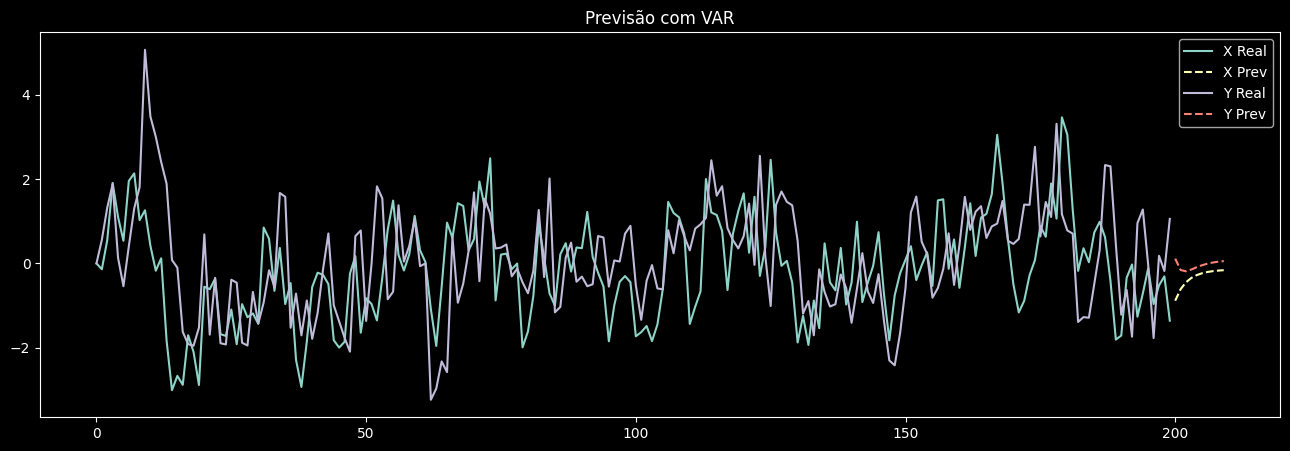

In [10]:
plt.figure(figsize=(16, 5))

for coluna in df.columns:
    plt.plot(df[coluna], label=f"{coluna} Real")
    plt.plot(range(len(df), len(df)+10), df_previsao[coluna], '--', label=f"{coluna} Prev")

plt.legend()
plt.title("Previsão com VAR")
plt.show()

## Causalidade de Granger

Verifica s euma variável ajuda a prever outra.

Exemplo:
- X causa Y?

In [12]:
# Teste de Granger

resultado_granger = modelo_ajustado.test_causality('Y', ['X'], kind='f')
print(resultado_granger.summary())

Granger causality F-test. H_0: X does not Granger-cause Y. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         28.98          3.865   0.000 (1, 392)
----------------------------------------------


## Conclusão 

Neste notebook, aprendeu-se:

- O que são séries multivaridas
- Como funciona o modelo VAR
- Como ajustar e prever o VAR
- Como analisar causalidade Grander

## Próximo passo:

VARMAX (VAR + variáveis exógenas + ruído MA)

Esse será o modelo central do projeto